In [ ]:
# add drive colab
from google.colab import drive
drive.mount("/content/mydrive")

Mounted at /content/mydrive


In [ ]:
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
!pip install japanize-matplotlib
import japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 10.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=d32fa52d93efd16b7a581e7dea3f53a9578f9b154a91a339d252151450fd5c55
  Stored in directory: /root/.cache/pip/wheels/56/8b/41/7c8a47025c6eef46f0b7488f2510fff13e48f1e7d5bf26e21b
Successfully built japanize-matplotlib


報告書pdfから、必要なページを抜き出して新しいpdfを作る

In [ ]:
# PDF操作用のライブラリをインストール
!pip install pypdf
from pypdf import PdfReader, PdfWriter

In [ ]:
# ------------------------------------------------------
# 報告書pdfから、必要なページを抜き出して新しいpdfを作る「関数」
# ------------------------------------------------------

def extract_pages_from_pdf(input_pdf_path, output_pdf_path, target_pages):

    """
    PDFから特定のページを抽出して新しいPDFを作成する関数
    """
    reader = PdfReader(input_pdf_path)
    writer = PdfWriter()

    # ----- 欲しいページを追加 --------
    for page_num in target_pages:
        if 1 <= page_num <= len(reader.pages):
            page = reader.pages[page_num - 1]
            writer.add_page(page)
        else:
            print(f"警告: ページ {page_num} は存在しません。")

    # ----- 新しいPDFファイルを作成 -----
    with open(output_pdf_path, "wb") as output_file:
        writer.write(output_file)

    print(f"抽出完了: {output_pdf_path} を作成しました。")


In [ ]:
# -------------   Main -----------------
# pdf fileの読み込み
path = "/content/drive/MyDrive/38_自然言語処理/市民アンケート(2026)/2026/"
name = "R6年度市民意識調査.pdf"
input_file = path + name

# 保存する新しいPDFファイル名 ＊＊＊注意上書き＊＊＊
output_name = "調査票.pdf"
output_file = path + output_name

# 注意：実際のPDFに印字されているページ番号ではなく、PDF全体でのページ
# 例) pages_ = [15, 20] + list(range(40, 46))
# ---------------------------
# ほしいページの番号を入れる
# ---------------------------
pages = [n for n in range(226, 238, 1)]

# 関数の実行
extract_pages_from_pdf(input_file, output_file, pages)

csvフアイルを読み込む、Dataframeにする

In [ ]:
# csvフアイルを読み込む
path ="/content/mydrive/MyDrive/38_自然言語処理/市民アンケート(2026)/2026/R6_citizen_voices.csv"
df = pd.read_csv(path, encoding="utf-8-sig")
display(df)

,カテゴリー,性別,年齢,居住地区,市民の声
0,都市基盤の整備について,女性,20～29 歳,松山地区,美原町の街灯が少ない夜道怖い
1,都市基盤の整備について,女性,20～29 歳,高坂丘陵地区,高坂駅から出るバスの本数が少ない。（特に土日、祝、夜 23：00 頃までの時間）デマンドタク...
2,都市基盤の整備について,男性,30～39 歳,野本地区,私の住んでいる地域では、道路に歩道がなく、安心して子どもと歩くことができない道路があります。...
3,都市基盤の整備について,女性,30～39 歳,高坂丘陵地区,小学生が夏休みに遊ぶことのできる施設が極端に少ないと感じます。暑い最中、外で遊ぶこともできず...
4,都市基盤の整備について,女性,40～49 歳,野本地区,若松町一丁目交差点を改善してほしい。（歩行者分離、矢印信号など信号が変わっても右折の車が途切...
...,...,...,...,...,...
100,その他,男性,50～59 歳,松山地区,東松山市は住みやすい街で大好きです。これからも更に暮らしやすい魅力ある街づくりをお願いします。
101,その他,女性,50～59 歳,高坂丘陵地区,目先の新しさや近代的な物ばかりではなく、人も環境も昔の良かった所は無くさないようにして欲しいです。
102,その他,女性,60～69 歳,唐子地区,東松山出身者です。自分の子や孫に胸を張って東松山市は教育環境、又、住み良い町であると言いたい...
103,その他,男性,70～79 歳,平野地区,他の成功モデルの自治体を参考にしながら 20年、30 年先を見据えた、自然豊かな東松山市のま...


たくさんのcsvフアイルを１個に結合する　マージする

In [ ]:
import glob
import pandas as pd

# 例: 'data_folder/' フォルダ内にあるすべての .csv ファイル
csv_files = glob.glob("/content/mydrive/MyDrive/38_自然言語処理/市民アンケート(2026)/2026/R6東松山市民アンケートRev(*).csv")

# 2. リスト内包表記ですべてのファイルをDataFrameとして読み込み、リストに格納
df_list = [pd.read_csv(file) for file in csv_files]
print(f"合計 {len(csv_files)} 個のファイルを結合(マージ)しました。", "\n")

# 3. 縦方向（行方向）に結合
# ignore_index=True で結合後のインデックスを振り直します
df = pd.concat(df_list, ignore_index=True)
display(df)

# 4. 新しいCSVファイルとして保存
path ="/content/mydrive/MyDrive/38_自然言語処理/市民アンケート(2026)/2026/R6東松山市民の意見(all).csv"

# encoding='utf-8-sig' はExcelで開いた際の文字化けを防ぎます
df.to_csv(path, index=False, encoding="utf-8-sig")

print(f"------ フアイルを保存しました。 -----")

合計 11 個のファイルを結合(マージ)しました。 



,分野,性別,年齢,居住地区,市民の声,ラベル
0,都市基盤の整備について,女性,20~29歳,松山地区,美原町の街灯が少ないので夜道が怖い,0
1,都市基盤の整備について,女性,20~29歳,高坂丘陵地区,高坂駅から出るバスの本数が少ない。(特に土日、祝、夜23:00頃までの時間) デマンドタクシ...,0
2,都市基盤の整備について,男性,30~39歳,野本地区,私の住んでいる地域では、道路に歩道がなく、安心して子どもと歩くことができない道路があります。...,0
3,都市基盤の整備について,女性,30~39歳,高坂丘陵地区,小学生が夏休みに遊ぶことのできる施設が極端に少ないと感じます。暑い最中、外で遊ぶこともできず...,0
4,都市基盤の整備について,女性,40~49歳,野本地区,若松町一丁目交差点を改善してほしい。(歩行者分離、矢印信号など信号が変わっても右折の車が途切...,0
...,...,...,...,...,...,...
100,その他,男性,50~59歳,松山地区,東松山市は住みやすい街で大好きです。これからも更に暮らしやすい魅力ある街づくりをお願いします。,10
101,その他,女性,50~59歳,高坂丘陵地区,目先の新しさや近代的な物ばかりではなく、人も環境も昔の良かった所は無くさないようにして欲しいです。,10
102,その他,女性,60~69歳,唐子地区,東松山出身者です。自分の子や孫に胸を張って東松山市は教育環境、また、住み良い町であると言いた...,10
103,その他,男性,70~79歳,平野地区,他の成功モデルの自治体を参考にしながら20年、30年先を見据えた自然豊かな東松山市のまちづく...,10


------ フアイルを保存しました。 -----


新しく一つに統合したcsvフアイルを読み込む

In [ ]:
# 新しく一つに統合したcsvフアイルを読み込む

path ="/content/mydrive/MyDrive/38_自然言語処理/市民アンケート(2026)/2026/R6東松山市民の意見(all).csv"
df = pd.read_csv(path, encoding="utf-8-sig")
display(df)

,分野,性別,年齢,居住地区,市民の声,ラベル
0,都市基盤の整備について,女性,20~29歳,松山地区,美原町の街灯が少ないので夜道が怖い,0
1,都市基盤の整備について,女性,20~29歳,高坂丘陵地区,高坂駅から出るバスの本数が少ない。(特に土日、祝、夜23:00頃までの時間) デマンドタクシ...,0
2,都市基盤の整備について,男性,30~39歳,野本地区,私の住んでいる地域では、道路に歩道がなく、安心して子どもと歩くことができない道路があります。...,0
3,都市基盤の整備について,女性,30~39歳,高坂丘陵地区,小学生が夏休みに遊ぶことのできる施設が極端に少ないと感じます。暑い最中、外で遊ぶこともできず...,0
4,都市基盤の整備について,女性,40~49歳,野本地区,若松町一丁目交差点を改善してほしい。(歩行者分離、矢印信号など信号が変わっても右折の車が途切...,0
...,...,...,...,...,...,...
100,その他,男性,50~59歳,松山地区,東松山市は住みやすい街で大好きです。これからも更に暮らしやすい魅力ある街づくりをお願いします。,10
101,その他,女性,50~59歳,高坂丘陵地区,目先の新しさや近代的な物ばかりではなく、人も環境も昔の良かった所は無くさないようにして欲しいです。,10
102,その他,女性,60~69歳,唐子地区,東松山出身者です。自分の子や孫に胸を張って東松山市は教育環境、また、住み良い町であると言いた...,10
103,その他,男性,70~79歳,平野地区,他の成功モデルの自治体を参考にしながら20年、30年先を見据えた自然豊かな東松山市のまちづく...,10


それぞれの居住地区の回答数を調べる

In [ ]:
category = df["居住地区"].nunique()
print(f"居住地区は{category}種類です。")
category_list = df["居住地区"].unique().tolist()
category_dict = df['居住地区'].value_counts().to_dict()

df_category = pd.DataFrame(list(category_dict.items()), columns=['居住地区', 'アンケート回答数'])
display(df_category)


居住地区は7種類です。


,居住地区,アンケート回答数
0,松山地区,37
1,高坂地区,17
2,野本地区,16
3,唐子地区,14
4,高坂丘陵地区,8
5,平野地区,8
6,大岡地区,5


In [ ]:
# 居住地区が全部で何箇所あるか（数値）調べる
num_areas = df["居住地区"].nunique()
print(f"居住地区は全部で {num_areas} 箇所です。")
area_list = df["居住地区"].unique().tolist()
print(area_list,"\n")

category = df["分野"].nunique()
print(f"分野は{category}種類です。")
category_list = df["分野"].unique().tolist()
print(category_list, "\n")

age = df["年齢"].nunique()
print(f"年齢は{age}種類です。")
age_list = ['18~19歳', '20~29歳', '30~39歳', '40~49歳', '50~59歳', '60~69歳', '70~79歳', '80歳以上']
print(age_list, "\n")

gender = df["性別"].nunique()
print(f"性別は{gender}種類です。")
gender_list = df["性別"].unique().tolist()
print(gender_list, "\n")

居住地区は全部で 7 箇所です。
['松山地区', '高坂丘陵地区', '野本地区', '唐子地区', '平野地区', '大岡地区', '高坂地区'] 

分野は11種類です。
['都市基盤の整備について', '駅周辺や商店街の活性化について', '環境について', '防災・防犯・安全について', '保健・医療・福祉について', '教育・文化・スポーツについて', '産業について', '情報について', '観光について', '市政について', 'その他'] 

年齢は8種類です。
['18~19歳', '20~29歳', '30~39歳', '40~49歳', '50~59歳', '60~69歳', '70~79歳', '80歳以上'] 

性別は2種類です。
['女性', '男性'] 



# 居住地区とアンケート回収の数

In [ ]:
# 居住地区とアンケート回収の数

# カラムのデータを集計して辞書に変換
area_dict = df['居住地区'].value_counts().to_dict()

df_area = pd.DataFrame(list(area_dict.items()), columns=['居住地区', 'アンケート回答数'])
display(df_area)

,居住地区,アンケート回答数
0,松山地区,37
1,高坂地区,17
2,野本地区,16
3,唐子地区,14
4,高坂丘陵地区,8
5,平野地区,8
6,大岡地区,5


アンケート回答数のグラフをつくる

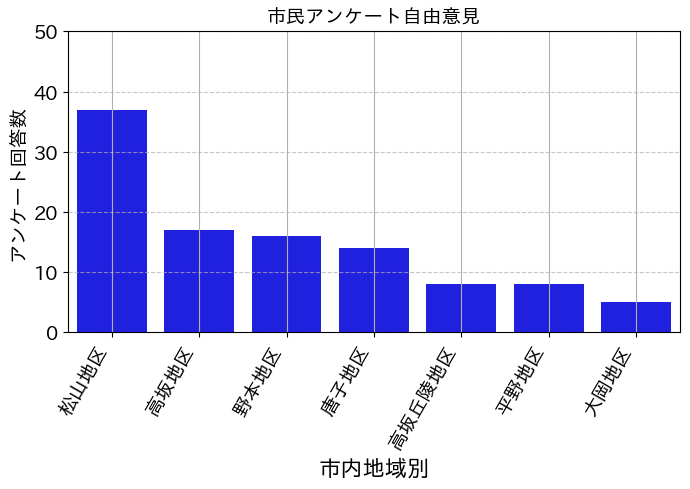

In [ ]:
# グラフ作成

plt.figure(figsize=(7, 5))

sns.barplot(x="居住地区", y="アンケート回答数", data=df_area, color="blue")

plt.title("市民アンケート自由意見",  fontsize=14)
plt.xticks(rotation=60, ha="right", fontsize=14)
plt.xlabel("市内地域別", fontsize=16)
plt.ylabel("アンケート回答数", fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, 50)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.grid(True)
plt.show()

回答を分類する

分野は11種類です。


,分野,アンケート回答数
0,都市基盤の整備について,19
1,駅周辺や商店街の活性化について,14
2,保健・医療・福祉について,14
3,教育・文化・スポーツについて,14
4,その他,12
5,市政について,9
6,産業について,7
7,防災・防犯・安全について,6
8,環境について,5
9,情報について,3


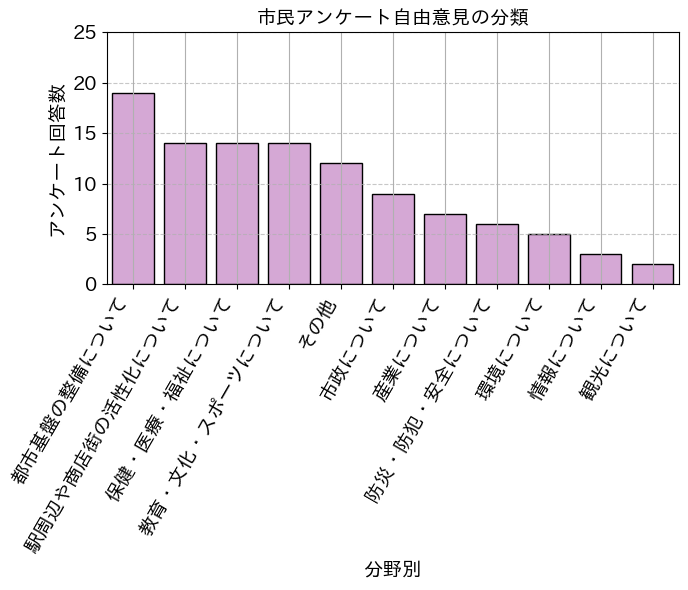

In [ ]:
# それぞれの回答の分野を分ける

category = df["分野"].nunique()
print(f"分野は{category}種類です。")
category_list = df["分野"].unique().tolist()
category_dict = df['分野'].value_counts().to_dict()

df_category = pd.DataFrame(list(category_dict.items()), columns=['分野', 'アンケート回答数'])
display(df_category)

# グラフ作成

plt.figure(figsize=(7, 6))

sns.barplot(x="分野", y="アンケート回答数", data=df_category, color="plum", edgecolor="black")

plt.title("市民アンケート自由意見の分類",  fontsize=14)
plt.xticks(rotation=60, ha="right", fontsize=14)
plt.xlabel("分野別", fontsize=14)
plt.ylabel("アンケート回答数", fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, 25)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.grid(True)
plt.show()

アンケートに回答した人の年齢

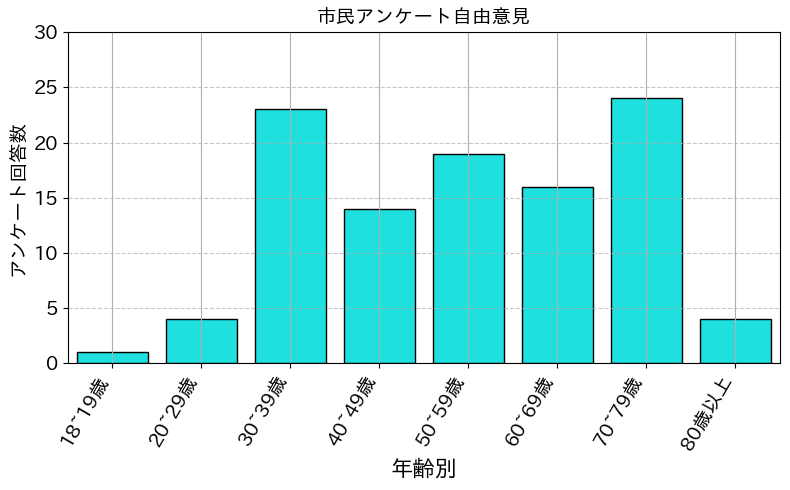

In [ ]:
# 年齢
import re

age_dict = df['年齢'].value_counts().to_dict()
# キーの先頭の数値を取り出してソート
sorted_dict = dict(
    sorted(
            age_dict.items(), key=lambda x: int(re.search(r'\d+', x[0]).group())
    )
)

df_age = pd.DataFrame(list(sorted_dict.items()), columns=['年齢', 'アンケート回答数'])

# グラフ作成
plt.figure(figsize=(8, 5))

sns.barplot(x="年齢", y="アンケート回答数", data=df_age, color="cyan", edgecolor="black")

plt.title("市民アンケート自由意見",  fontsize=14)
plt.xticks(rotation=60, ha="right", fontsize=14)
plt.xlabel("年齢別", fontsize=16)
plt.ylabel("アンケート回答数", fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, 30)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.grid(True)
plt.show()

性別

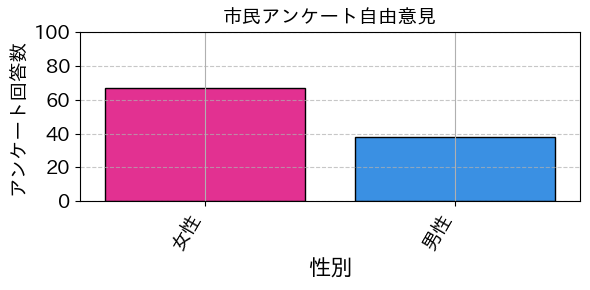

In [ ]:
gender_dict = df['性別'].value_counts().to_dict()
df_sex = pd.DataFrame(list(gender_dict.items()), columns=['性別', 'アンケート回答数'])

# グラフ作成
plt.figure(figsize=(6, 3))

sns.barplot(
    x="性別",
    y="アンケート回答数",
    hue="性別",
    data=df_sex,
    palette=["deeppink", "dodgerblue"],
    legend=False, edgecolor="black"
)

plt.title("市民アンケート自由意見",  fontsize=14)
plt.xticks(rotation=60, ha="right", fontsize=14)
plt.xlabel("性別", fontsize=16)
plt.ylabel("アンケート回答数", fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.grid(True)
plt.show()

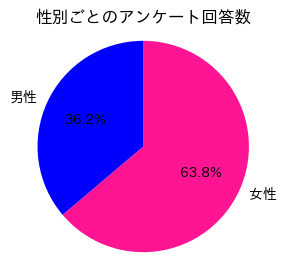

In [ ]:
# 性別

gender_dict = df['性別'].value_counts().to_dict()
df_sex = pd.DataFrame(list(gender_dict.items()), columns=['性別', 'アンケート回答数'])


# 円グラフの描画
plt.figure(figsize=(3, 3))

colors = ["blue" if x == "男性" else "deeppink" for x in df_sex["性別"]]
plt.pie(
    df_sex['アンケート回答数'],
    labels=df_sex["性別"],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)
plt.title('性別ごとのアンケート回答数')
plt.axis('equal')        # 円を綺麗な正円にする
plt.show()

回答してくれた人の居住地と性別

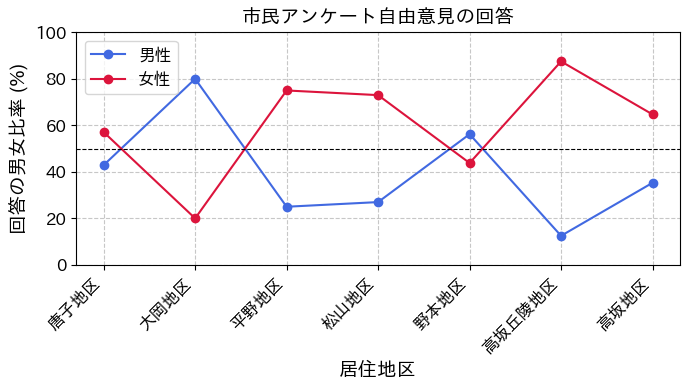

In [ ]:
# 居住地と性別

# normalize="index" で行（居住地）ごとの合計が1（100%）になるように割合を計算
df_ratio = pd.crosstab(df["居住地区"], df["性別"], normalize="index")

df_pct = (df_ratio * 100).round(1)

plt.figure(figsize=(7, 4))

plt.plot(df_pct.index, df_pct["男性"], marker="o", label="男性", color="royalblue")
plt.plot(df_pct.index, df_pct["女性"], marker="o", label="女性", color="crimson")
plt.axhline(y=50, color='black', linestyle='--', linewidth=0.8)

plt.title("市民アンケート自由意見の回答",  fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=12)

# ラベルと目盛りの設定
plt.xlabel("居住地区", fontsize=14)
plt.ylabel("回答の男女比率 (%)", fontsize=14)
plt.yticks(fontsize=12)

# パーセンテージの比較なので、Y軸の範囲を0〜100に固定して視覚的なブレを防ぐ
plt.ylim(0, 100)

# 背景グリッドと凡例の表示
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(fontsize=12, loc="best")

# レイアウトの自動調整
plt.tight_layout()
plt.show()

アンケートしてくれた内容　地域別

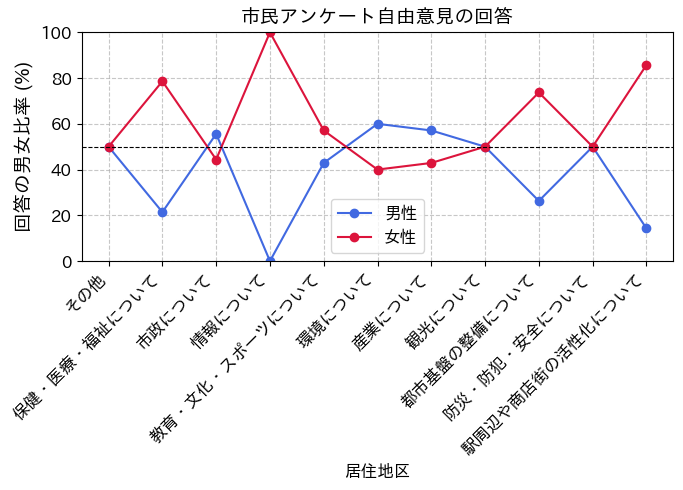

In [ ]:
# アンケート内容の分類

df_ratio = pd.crosstab(df["分野"], df["性別"], normalize="index")
df_pct = (df_ratio * 100).round(1)

plt.figure(figsize=(7, 5))

plt.plot(df_pct.index, df_pct["男性"], marker="o", label="男性", color="royalblue")
plt.plot(df_pct.index, df_pct["女性"], marker="o", label="女性", color="crimson")
plt.axhline(y=50, color='black', linestyle='--', linewidth=0.8)

# X軸のラベル（
plt.xticks(rotation=45, ha="right", fontsize=12)

# ラベルと目盛りの設定
plt.title("市民アンケート自由意見の回答",  fontsize=14)
plt.xlabel("居住地区", fontsize=12)
plt.ylabel("回答の男女比率 (%)", fontsize=14)
plt.yticks(fontsize=12)

plt.ylim(0, 100)

# 背景グリッドと凡例の表示
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(fontsize=12, loc="best")

# レイアウトの自動調整
plt.tight_layout()
plt.show()

回答してくれた人の年齢

<Figure size 600x400 with 0 Axes>

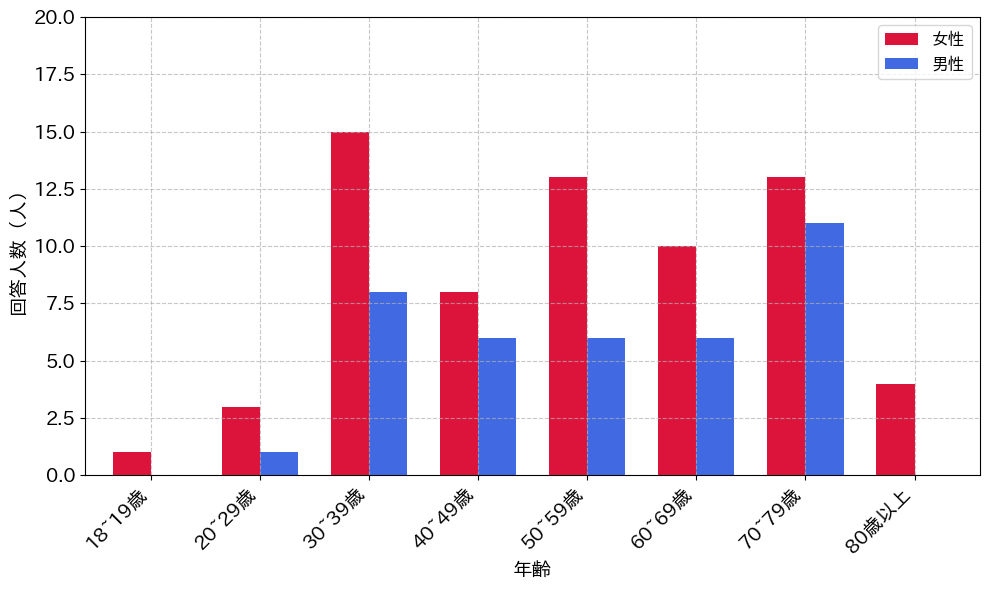

In [ ]:
# 回答してくれた人の年齢

df_count = pd.crosstab(df["年齢"], df["性別"])

plt.figure(figsize=(6, 4))
#plt.title("市民アンケート自由意見",  fontsize=14)
ax = df_count.plot.bar(figsize=(10, 6), color=["crimson", "royalblue"], width=0.7)

plt.xticks(rotation=45, ha="right", fontsize=14)
# ラベルと目盛りの設定
plt.xlabel("年齢", fontsize=14)
plt.ylabel("回答人数（人）", fontsize=14)  # Y軸を「割合」から「人数」に変更
plt.yticks(fontsize=14)
plt.ylim(0, 20)

# 背景グリッドと凡例の表示
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(fontsize=12, loc="best")

# レイアウトの自動調整
plt.tight_layout()
plt.show()

居住地区別の意見

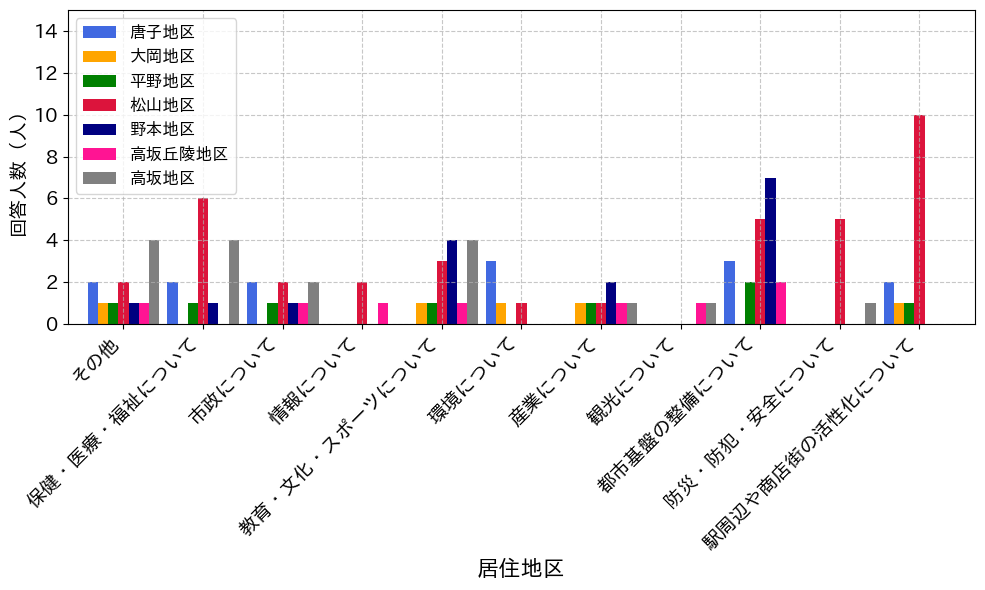

In [ ]:
# 居住地区の要望

df_table = pd.crosstab(df["分野"], df["居住地区"])
# display(df_table.loc["松山地区"])

# ---- グラフ作成　------
color_index = ["royalblue", "orange", "green", "crimson", "navy", "deeppink", "gray"]
ax = df_table.plot.bar(figsize=(10, 6), color=color_index, width=0.9)

plt.xticks(rotation=45, ha="right", fontsize=14)
# ラベルと目盛りの設定
plt.xlabel("居住地区", fontsize=16)
plt.ylabel("回答人数（人）", fontsize=14)  # Y軸を「割合」から「人数」に変更
plt.yticks(fontsize=14)
plt.ylim(0, 15)

# 背景グリッドと凡例の表示
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(fontsize=12, loc="best")

# レイアウトの自動調整
plt.tight_layout()
plt.show()

アンケートに回答した人の地区別年齢

In [ ]:
# 年齢別の回答数

df_table = pd.crosstab(df["居住地区"], df["年齢"])
#display(df_table.loc["松山地区"])
display(df_table)


年齢,18~19歳,20~29歳,30~39歳,40~49歳,50~59歳,60~69歳,70~79歳,80歳以上
居住地区,,,,,,,,
唐子地区,0,0,2,3,3,4,2,0
大岡地区,0,1,0,0,0,0,4,0
平野地区,0,0,0,3,0,1,4,0
松山地区,1,1,8,5,8,6,6,2
野本地区,0,0,2,1,4,4,4,1
高坂丘陵地区,0,2,2,0,1,1,1,1
高坂地区,0,0,9,2,3,0,3,0
